In [52]:
import torch
import torch.nn.functional as F
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from encoder import inference as encoder
from synthesizer.inference import Synthesizer
from pathlib import Path
import librosa
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE


In [ ]:
# Load models
encoder.load_model(Path("models/encoder.pt"))
synthesizer = Synthesizer(Path("models/synthesizer.pt")) 
synth_checkpoint = torch.load("models/synthesizer.pt", map_location="cpu")

c:\Varun\Major Project\EchoAI\encoder\inference.py:32: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(weights_fpath, _device)
c:\Varun\Major Project\E

Loaded encoder "encoder.pt" trained to step 1564501
Synthesizer using device: cuda
Building Wave-RNN
Trainable Parameters: 4.481M
Loading model weights at models/vocoder.pt


C:\Users\soumy\AppData\Local\Temp\ipykernel_13780\1903201538.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  synth_checkpoint = torch.load("models/synthesizer.pt", map_l

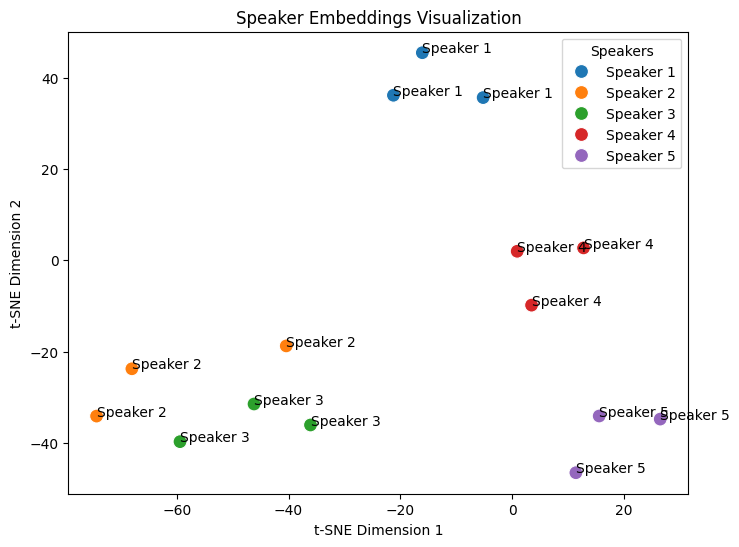

In [ ]:
# Speaker Encoder Analysis
wav_files = [
    ("Speaker 1", "datasets/vctk/wav48/p225/p225_001.wav"),
    ("Speaker 1", "datasets/vctk/wav48/p225/p225_002.wav"),
    ("Speaker 1", "datasets/vctk/wav48/p225/p225_003.wav"),
    ("Speaker 2", "datasets/vctk/wav48/p226/p226_001.wav"),
    ("Speaker 2", "datasets/vctk/wav48/p226/p226_002.wav"),
    ("Speaker 2", "datasets/vctk/wav48/p226/p226_003.wav"),
    ("Speaker 3", "datasets/vctk/wav48/p227/p227_001.wav"),
    ("Speaker 3", "datasets/vctk/wav48/p227/p227_002.wav"),
    ("Speaker 3", "datasets/vctk/wav48/p227/p227_003.wav"),
    ("Speaker 4", "datasets/vctk/wav48/p228/p228_001.wav"),
    ("Speaker 4", "datasets/vctk/wav48/p228/p228_002.wav"),
    ("Speaker 4", "datasets/vctk/wav48/p228/p228_003.wav"),
    ("Speaker 5", "datasets/vctk/wav48/p229/p229_001.wav"),
    ("Speaker 5", "datasets/vctk/wav48/p229/p229_002.wav"),
    ("Speaker 5", "datasets/vctk/wav48/p229/p229_003.wav")
]

embeddings = []
speaker_labels = []  

for speaker, wav_path in wav_files:
    wav, _ = librosa.load(wav_path, sr=16000)
    emb = encoder.embed_utterance(wav) 
    embeddings.append(emb)
    speaker_labels.append(speaker)  

# Convert to NumPy array
embeddings = np.array(embeddings)

# Apply t-SNE for dimensionality reduction
n_samples = len(embeddings)
perplexity = min(n_samples - 1, 5)  
tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings)

# Plot the embeddings with speaker labels
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=embeddings_2d[:, 0], y=embeddings_2d[:, 1], 
    hue=speaker_labels, palette="tab10", s=100  
)


for i, (speaker, _) in enumerate(wav_files):
    plt.annotate(speaker, (embeddings_2d[i, 0], embeddings_2d[i, 1]))

plt.title("Speaker Embeddings Visualization")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(title="Speakers")
plt.show()


In [ ]:
# Synthesizer Analysis
import torch
import torch.nn.functional as F

# Target Spectogram
mel_target = torch.randn(1, 80, 20, dtype=torch.float32)  

# Generate synthesized mel spectrogram
mel_pred = synthesizer.synthesize_spectrograms(["Hello World"], [torch.randn(256)])[0]
mel_pred_tensor = torch.tensor(mel_pred, dtype=torch.float32)
mel_pred_tensor = mel_pred_tensor.unsqueeze(0) 

if mel_pred_tensor.shape[-1] > mel_target.shape[-1]:  
    mel_pred_tensor = mel_pred_tensor[:, :, :mel_target.shape[-1]]
elif mel_pred_tensor.shape[-1] < mel_target.shape[-1]:  
    mel_target = mel_target[:, :, :mel_pred_tensor.shape[-1]]

# Compute loss
loss = F.mse_loss(mel_pred_tensor, mel_target)
print("Synthesizer Loss:", loss.item())



| Generating 1/1


Done.

Synthesizer Loss: 4.925691604614258


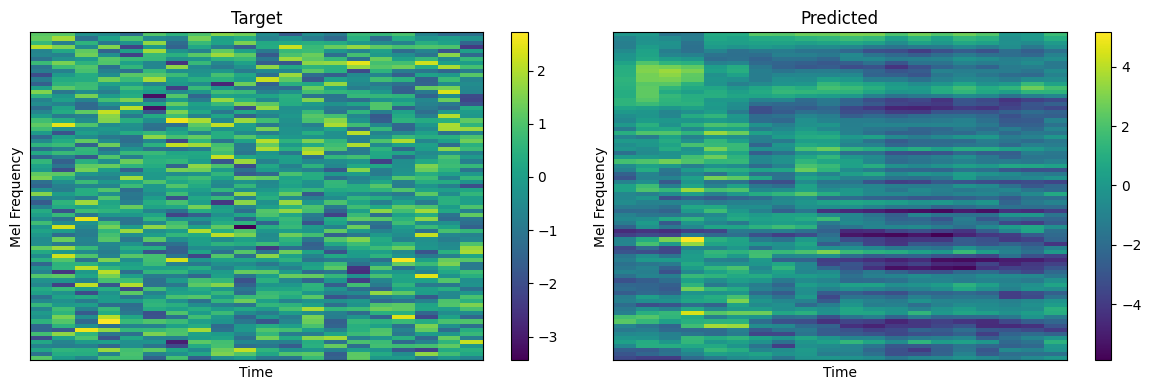

In [ ]:
def plot_mel_spectrograms(mel_target, mel_pred, titles=("Target Mel", "Predicted Mel")):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Target Mel Spectrogram
    img1 = librosa.display.specshow(mel_target.numpy(), sr=16000, hop_length=256, cmap="viridis", ax=axes[0])
    axes[0].set_title(titles[0])
    axes[0].set_xlabel("Time")
    axes[0].set_ylabel("Mel Frequency")
    fig.colorbar(img1, ax=axes[0])

    # Predicted Mel Spectrogram
    img2 = librosa.display.specshow(mel_pred.numpy(), sr=16000, hop_length=256, cmap="viridis", ax=axes[1])
    axes[1].set_title(titles[1])
    axes[1].set_xlabel("Time")
    axes[1].set_ylabel("Mel Frequency")
    fig.colorbar(img2, ax=axes[1])

    plt.tight_layout() 
    plt.show()

plot_mel_spectrograms(mel_target.squeeze(0), mel_pred_tensor.squeeze(0))


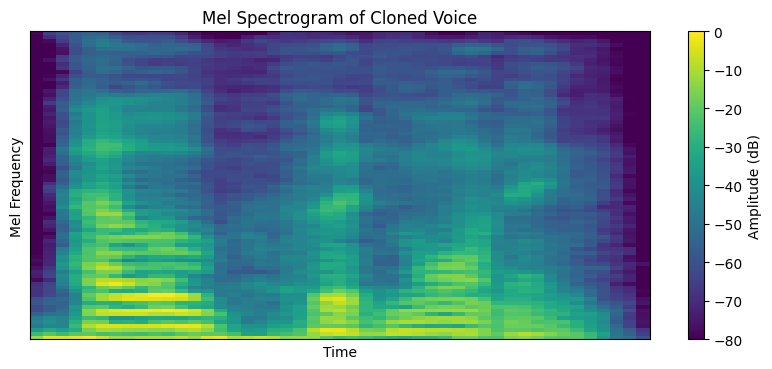

In [45]:
# Mel Spectogram of the Cloned Voice Output Audio
sample_wav_path = "samples/cloned_voice_p226_03.wav"
wav, sr = librosa.load(sample_wav_path, sr=16000)
mel_spectrogram = librosa.feature.melspectrogram(y=wav, sr=sr, n_mels=80)

plt.figure(figsize=(10, 4))
librosa.display.specshow(librosa.power_to_db(mel_spectrogram, ref=np.max), sr=sr, hop_length=256, cmap="viridis")
plt.colorbar(label="Amplitude (dB)")
plt.title("Mel Spectrogram of Cloned Voice")
plt.xlabel("Time")
plt.ylabel("Mel Frequency")
plt.show()
